# 07 — Chronos-2 LoRA Fine-Tuning

This notebook fine-tunes Chronos-2, the best-performing zero-shot model from the previous experiments, using Low-Rank Adaptation (LoRA). The fine-tuned model is evaluated using the same forecasting and evaluation pipeline as `03_chronos_forecasting`, allowing the impact of fine-tuning to be assessed without changing any other part of the experimental setup. The final results are appended to `../results/comparison.csv` as **Chronos-2 (fine-tuned)** for comparison with the zero-shot model.

The dataset and preprocessing remain unchanged from the zero-shot experiment. A complete 15-minute time series, including nighttime observations (`power = 0`), is used to create 512-step input windows and 96-step forecasting horizons. Model performance is evaluated only during daytime (`solar_elevation > 5°`) using the same evaluation metrics and forecasting windows as in the zero-shot setting.

Fine-tuning is performed exclusively on the training data (before `2020-01-01`). A small validation set, taken from the end of the training period, is used for checkpoint selection, while the test set remains untouched throughout training. Weather and time features are provided as future covariates during both fine-tuning and inference, matching the experimental setup used in the zero-shot Chronos-2 notebook.

To reduce training cost, LoRA is applied instead of updating all model parameters. The base Chronos-2 model remains frozen while lightweight adapter layers are trained, making fine-tuning significantly faster and more memory-efficient with only a small number of additional trainable parameters. During inference, predictions are generated using the fine-tuned model through the same `predict_df()` interface as the zero-shot model.

> **Requirements:** A CUDA-enabled GPU and `chronos-forecasting>=2.0` with `peft` installed (`pip install "chronos-forecasting>=2.0" peft`).

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from chronos import Chronos2Pipeline           # pip install "chronos-forecasting>=2.0"
from transformers import EarlyStoppingCallback  # for checkpoint selection / early stopping

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

FIG_PREFIX = '07'
print('Libraries loaded ✓ | torch', torch.__version__, '| CUDA', torch.cuda.is_available())

Libraries loaded ✓ | torch 2.12.1 | CUDA False


In [2]:
# ---- Benchmark configuration (IDENTICAL across every TSFM notebook) ----
SEED              = 321
CONTEXT_LENGTH    = 512          # past steps fed to the model   (5.33 days @ 15 min)
PREDICTION_LENGTH = 96           # forecast horizon              (24 h  @ 15 min)
STRIDE            = 96           # non-overlapping -> one 24h forecast per day
ELEV_THRESHOLD    = 5.0          # daytime filter: solar_elevation > 5 deg (HORIZON only)

TEST_START = pd.Timestamp('2020-01-01')
TEST_END   = pd.Timestamp('2020-08-01')

TARGET = 'power'
# measured weather = KNOWN-FUTURE covariates (proxy for a *perfect* weather forecast)
WEATHER_COVS = ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance',
                'sun_zenith', 'sun_azimuth', 'temperature']
TIME_COVS    = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']   # deterministic, known ahead
FUTURE_COVS  = WEATHER_COVS + TIME_COVS

np.random.seed(SEED)
print(f'context = {CONTEXT_LENGTH} ({CONTEXT_LENGTH*15/60/24:.2f} d) | '
      f'horizon = {PREDICTION_LENGTH} (24 h) | stride = {STRIDE}')
print(f'{len(FUTURE_COVS)} future covariates:', FUTURE_COVS)

context = 512 (5.33 d) | horizon = 96 (24 h) | stride = 96
10 future covariates: ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance', 'sun_zenith', 'sun_azimuth', 'temperature', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 2. Load dataset.csv

In [3]:
df_raw = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)

# Same timezone handling as 02_baseline_forecasting: UTC -> Europe/Zagreb -> drop tz
local_tz = 'Europe/Zagreb'
df_raw.index = df_raw.index.tz_localize('UTC').tz_convert(local_tz).tz_localize(None)

print('raw:', df_raw.shape, '|', df_raw.index.min(), '->', df_raw.index.max())
df_raw.head(3)

raw: (2204759, 7) | 2018-04-17 07:24:00 -> 2023-03-04 23:54:00


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance
timestamp,,,,,,,
2018-04-17 07:24:00,0.00005,77.63,-92.47,14.1,7,0,7
2018-04-17 07:25:00,0.00005,77.46,-92.29,14.1,8,0,8
2018-04-17 07:26:00,0.00005,77.28,-92.12,14.1,8,0,8


## 3. Build the full regular 15-min grid

Night rows are kept (power = 0) so the model sees the daily cycle; the daytime filter is applied later, at evaluation, on the forecast horizon only.

In [4]:
# Resample to 15 min: power SUMMED (-> kWh per 15 min), weather AVERAGED  (same as baseline)
agg = {'power': 'sum', 'sun_zenith': 'mean', 'sun_azimuth': 'mean', 'temperature': 'mean',
       'global_irradiance': 'mean', 'direct_irradiance': 'mean', 'diffuse_irradiance': 'mean'}
df = df_raw.resample('15min', closed='left', label='left').agg(agg)

# KEY DIFFERENCE vs baseline: the baseline drops nighttime (power>0), which breaks the
# regular grid TSFMs require. Instead we keep the FULL, evenly-spaced 15-min grid so the
# model sees the diurnal cycle, and set night power to 0 (no sun -> no output).
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='15min')
df = df.reindex(full_idx)
df.index.name = 'timestamp'

df['power'] = df['power'].fillna(0.0).clip(lower=0)
irr = ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance']
df[irr] = df[irr].clip(lower=0)
df[WEATHER_COVS] = df[WEATHER_COVS].interpolate(limit_direction='both')

# Solar elevation for the daytime filter (dataset has sun_zenith; elevation = 90 - zenith)
df['solar_elevation'] = 90.0 - df['sun_zenith']

# Deterministic time covariates (known for the future horizon)
_h = df.index.hour + df.index.minute / 60.0
_d = df.index.dayofyear
df['hour_sin'] = np.sin(2*np.pi*_h/24.0); df['hour_cos'] = np.cos(2*np.pi*_h/24.0)
df['doy_sin']  = np.sin(2*np.pi*_d/366.0); df['doy_cos'] = np.cos(2*np.pi*_d/366.0)

assert not df[FUTURE_COVS + ['power', 'solar_elevation']].isna().any().any(), 'NaNs remain'
print('full grid:', df.shape, '| night filled with 0, no NaNs')
df.head(3)

full grid: (171139, 12) | night filled with 0, no NaNs


,power,sun_zenith,sun_azimuth,temperature,global_irradiance,direct_irradiance,diffuse_irradiance,solar_elevation,hour_sin,hour_cos,doy_sin,doy_cos
timestamp,,,,,,,,,,,,
2018-04-17 07:15:00,0.000283,77.195000,-92.026667,14.100000,9.000000,0.0,9.0,12.805000,0.946930,-0.321439,0.964806,-0.262962
2018-04-17 07:30:00,0.003250,75.363333,-90.153333,14.200000,20.866667,0.0,20.8,14.636667,0.923880,-0.382683,0.964806,-0.262962
2018-04-17 07:45:00,0.018767,72.747333,-87.450000,14.446667,49.800000,0.0,49.8,17.252667,0.896873,-0.442289,0.964806,-0.262962


## 4. Rolling-window layout + metric helper

In [5]:
# Rolling-window layout (identical for every model):
#
#   context window           |  prediction horizon
#   [i-512 ----------- i)     |  [i ------------ i+96)
#        512 steps (5.3 d)    |     96 steps (24 h)
#                            (i = forecast origin, local midnight)
#
# stride = 96  -> non-overlapping, exactly one calendar day forward per window.
idx = df.index
o0, oN = idx.get_loc(TEST_START), idx.get_loc(TEST_END)
origins = list(range(o0, oN, STRIDE))

assert origins[0] - CONTEXT_LENGTH >= 0, 'not enough history before the first origin'
print(f'{len(origins)} forecast windows (2020-01-01 -> 2020-08-01)')
print(f'first origin : {idx[origins[0]]}  (context back to {idx[origins[0]-CONTEXT_LENGTH]})')
print(f'last  origin : {idx[origins[-1]]}  (horizon ends {idx[origins[-1]+PREDICTION_LENGTH-1]})')

213 forecast windows (2020-01-01 -> 2020-08-01)
first origin : 2020-01-01 00:00:00  (context back to 2019-12-26 16:00:00)
last  origin : 2020-07-31 00:00:00  (horizon ends 2020-07-31 23:45:00)


In [6]:
def evaluate(name, y_true, y_pred, fig_prefix=FIG_PREFIX):
    """MAE / RMSE / R2 / nRMSE + figures -- same conventions as 02_baseline_forecasting.
    nRMSE denominator = y_true.max() (identical actuals across models -> identical scale)."""
    y_pred = np.clip(y_pred, 0, None)
    y_true = np.asarray(y_true)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / y_true.max()

    print(f'\n[{name}]')
    print(f'  MAE   = {mae:.4f} kWh')
    print(f'  RMSE  = {rmse:.4f} kWh')
    print(f'  R2    = {r2:.4f}')
    print(f'  nRMSE = {nrmse:.4f}')

    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    lim = max(float(y_true.max()), float(y_pred.max())) * 1.05
    axes[0].scatter(y_true, y_pred, s=4, alpha=0.3)
    axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
    axes[0].set_title(f'{name}: Predicted vs Actual'); axes[0].grid(True)

    week = 7 * 24 * 4
    axes[1].plot(y_true[-week:], label='Actual')
    axes[1].plot(y_pred[-week:], label='Predicted')
    axes[1].set_title(f'{name}: last ~week of test samples')
    axes[1].set_ylabel('kWh'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    fname = f'../figure/{fig_prefix}_{slug}_eval.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved ->', fname)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nRMSE': nrmse}

## 5. Build fine-tuning inputs (train split + covariates, held-out validation)

In [7]:
# Fine-tuning data = TRAIN split only (< TEST_START). Hold out the last VAL_DAYS for checkpoint
# selection so the validation target never overlaps training -> no leakage into the 2020 test set.
# Chronos-2's fine-tuning API takes a list of task dicts:
#   target           : (num_series, T)   -> univariate here, so (1, T)
#   past_covariates  : {name: (T,)}      -> historical covariate values
#   future_covariates: {name: None}      -> "known-future"; Chronos builds future windows internally
#                                            during training. Real future values are supplied via
#                                            future_df at inference (same covariates as notebook 03).
VAL_DAYS = 14
val_cut  = TEST_START - pd.Timedelta(days=VAL_DAYS)

train_df = df[df.index < val_cut]        # the fit() only samples windows from here
val_df   = df[df.index < TEST_START]     # last PREDICTION_LENGTH steps = validation target (Dec 2019)

def make_task(frame):
    return {
        'target': frame['power'].to_numpy(dtype='float32')[None, :],                 # (1, T)
        'past_covariates':   {col: frame[col].to_numpy(dtype='float32') for col in FUTURE_COVS},
        'future_covariates': {col: None for col in FUTURE_COVS},
    }

train_inputs      = [make_task(train_df)]
validation_inputs = [make_task(val_df)]

print(f'train series : {len(train_df):,} steps  (-> {train_df.index.max()})')
print(f'val series   : {len(val_df):,} steps  (val target = last {PREDICTION_LENGTH} steps, ends {val_df.index.max()})')
print(f'no leakage: train ends {train_df.index.max()} < val target start {val_df.index[-PREDICTION_LENGTH]}')

train series : 58,531 steps  (-> 2019-12-17 23:45:00)
val series   : 59,875 steps  (val target = last 96 steps, ends 2019-12-31 23:45:00)
no leakage: train ends 2019-12-17 23:45:00 < val target start 2019-12-31 00:00:00


## 6. LoRA fine-tune Chronos-2

In [8]:
MODEL_NAME = 'Chronos-2 (fine-tuned)'
MODEL_KEY  = 'chronos2_finetuned'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# LoRA adapters on the attention projections + the output patch embedding.
LORA_CONFIG = {
    'r': 32,
    'lora_alpha': 64,
    'target_modules': [
        'self_attention.q', 'self_attention.k', 'self_attention.v', 'self_attention.o',
        'output_patch_embedding.output_layer',
    ],
}
NUM_STEPS     = 1000        # "light" fine-tuning; lower (e.g. 300) for a quick smoke-test
LEARNING_RATE = 2e-5
BATCH_SIZE    = 32

base_model = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map=DEVICE)

t0 = time.time()
fine_tuned_model = base_model.fit(
    train_inputs,
    prediction_length=PREDICTION_LENGTH,     # 96 = 24h, same task as test
    validation_inputs=validation_inputs,
    finetune_mode='lora',
    lora_config=LORA_CONFIG,
    context_length=CONTEXT_LENGTH,           # 512, same as zero-shot
    learning_rate=LEARNING_RATE,
    num_steps=NUM_STEPS,
    batch_size=BATCH_SIZE,
    output_dir='../results/chronos2_lora',
    finetuned_ckpt_name='checkpoint',
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
    save_steps=25,
    eval_steps=25,
)
finetune_time = time.time() - t0

pipeline = fine_tuned_model          # <- lets us reuse notebook 03's rolling predict_df loop verbatim
print(f'LoRA fine-tune finished in {finetune_time:.1f}s on {DEVICE}')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss
25,No log,0.036774
50,No log,0.041723
75,No log,0.040144
100,0.148788,0.039064
125,0.148788,0.037267
150,0.148788,0.035924
175,0.148788,0.035704
200,0.068910,0.034338
225,0.068910,0.031269
250,0.068910,0.031637


LoRA fine-tune finished in 523.4s on cpu


## 7. Rolling 24h-ahead forecast (fine-tuned model)

In [9]:
QUANTILES = [0.1, 0.5, 0.9]

def _median_col(pred_df):
    """Robustly pick the 0.5-quantile (median) column across chronos-forecasting versions."""
    for c in ['0.5', 0.5, 'predictions', 'mean', 'median']:
        if c in pred_df.columns:
            return c
    num = [c for c in pred_df.columns if c not in ('id', 'item_id', 'timestamp')]
    return num[len(num) // 2]

win_preds, win_acts, win_ts, win_infer = [], [], [], []

for k, i in enumerate(origins):
    ctx = df.iloc[i - CONTEXT_LENGTH:i]
    fut = df.iloc[i:i + PREDICTION_LENGTH]

    context_df = pd.DataFrame({'id': 'pv',
                               'timestamp': ctx.index.values,
                               'power': ctx['power'].values,
                               **{c: ctx[c].values for c in FUTURE_COVS}})
    future_df  = pd.DataFrame({'id': 'pv',
                               'timestamp': fut.index.values,
                               **{c: fut[c].values for c in FUTURE_COVS}})

    t0 = time.time()
    pred_df = pipeline.predict_df(context_df, future_df=future_df,
                                  prediction_length=PREDICTION_LENGTH,
                                  quantile_levels=QUANTILES,
                                  id_column='id', timestamp_column='timestamp',
                                  target='power')
    win_infer.append(time.time() - t0)

    win_preds.append(np.asarray(pred_df[_median_col(pred_df)].values, dtype=float))
    win_acts.append(fut['power'].values)
    win_ts.append(fut.index)
    if (k + 1) % 25 == 0:
        print(f'  {k + 1}/{len(origins)} windows')

print('Done:', len(origins), 'forecasts')

  25/213 windows
  50/213 windows
  75/213 windows
  100/213 windows
  125/213 windows
  150/213 windows
  175/213 windows
  200/213 windows
Done: 213 forecasts


## 8. Assemble forecasts, apply daytime filter, score

20448 horizon steps | 10109 daytime (49.4%)

[Chronos-2 (fine-tuned)]
  MAE   = 0.0281 kWh
  RMSE  = 0.0541 kWh
  R2    = 0.9432
  nRMSE = 0.0629


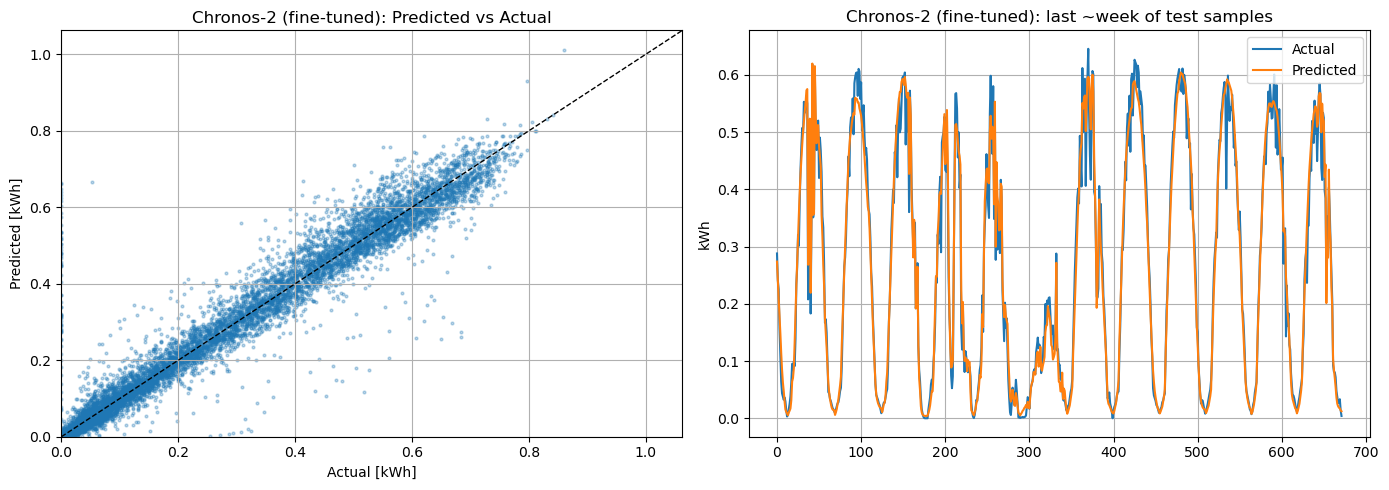

Saved -> ../figure/07_chronos-2_fine-tuned_eval.png

[Chronos-2 (fine-tuned) (all-hours)]
  MAE   = 0.0145 kWh
  RMSE  = 0.0381 kWh
  R2    = 0.9661
  nRMSE = 0.0444


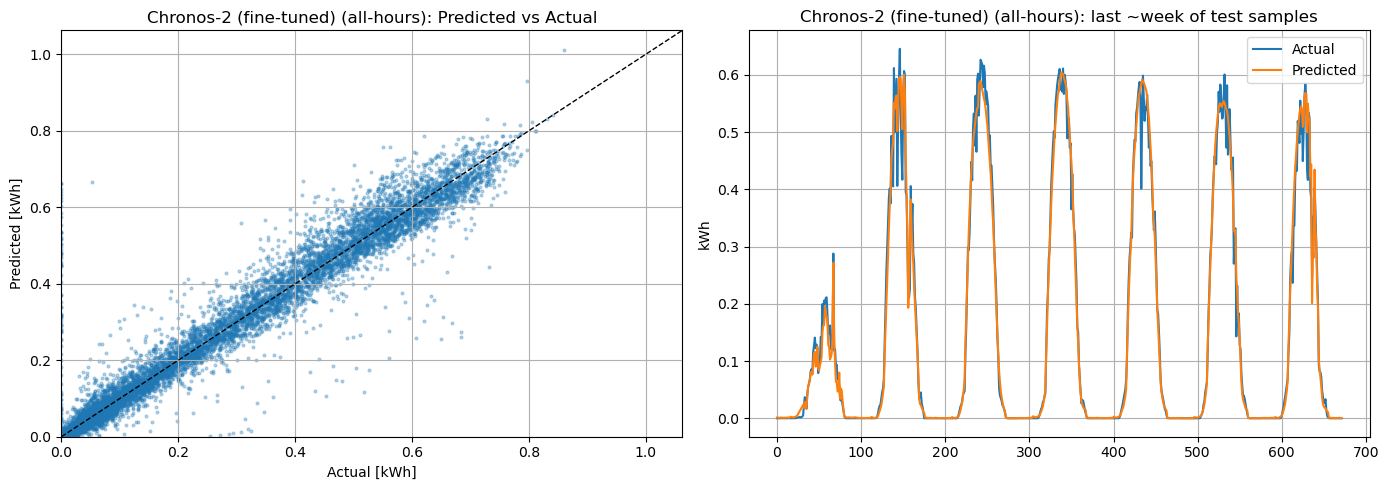

Saved -> ../figure/07_chronos-2_fine-tuned_all-hours_eval.png


In [10]:
# Stack every 24h horizon in chronological order
y_pred_full = np.concatenate(win_preds)                    # (n_windows * 96,)
y_true_full = np.concatenate(win_acts)
ts_full     = pd.DatetimeIndex(np.concatenate([t.values for t in win_ts]))

# Daytime filter applied to the PREDICTION timestamps only (context may contain night)
day_mask = df['solar_elevation'].reindex(ts_full).values > ELEV_THRESHOLD
print(f'{len(y_true_full)} horizon steps | {int(day_mask.sum())} daytime ({day_mask.mean():.1%})')

# ---- Headline (daytime) metrics: same evaluation set the baseline is scored on ----
res = evaluate(MODEL_NAME, y_true_full[day_mask], y_pred_full[day_mask])

# ---- All-hours metrics for completeness (brief asks for these too) ----
_ = evaluate(MODEL_NAME + ' (all-hours)', y_true_full, y_pred_full)

## 9. Save results (predictions + comparison.csv row)

In [11]:
# --- Inference cost (per 24h forecast) ---
total_infer = float(np.sum(win_infer))
per24       = total_infer / len(origins)
res['Train Time']     = finetune_time          # fine-tuning cost (vs 0 for zero-shot)
res['Inference Time'] = total_infer
print(f'Fine-tune {finetune_time:.1f}s | inference {total_infer:.1f}s total -> {per24:.3f}s per 24h forecast')

pd.DataFrame({'timestamp': ts_full,
              'actual':    y_true_full,
              MODEL_KEY:   np.clip(y_pred_full, 0, None),
              'is_daytime': day_mask}).to_pickle(f'../results/{MODEL_KEY}_predictions.pkl')
print(f'Saved -> ../results/{MODEL_KEY}_predictions.pkl')

comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']
new_rows  = pd.DataFrame([{k: res[k] for k in comp_cols}])
if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows
combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved -> {comp_path}\n')
print(combined[comp_cols].to_string(index=False))

Fine-tune 523.4s | inference 76.6s total -> 0.359s per 24h forecast
Saved -> ../results/chronos2_finetuned_predictions.pkl
Saved -> ../results/comparison.csv

                   Model      MAE     RMSE    nRMSE  Train Time  Inference Time
                LightGBM 0.021175 0.034823 0.040512    0.776353        0.014204
        LightGBM (tuned) 0.020895 0.034539 0.040182   48.507317        0.033761
                     MLP 0.020945 0.034464 0.040095    3.505997        0.009781
   Chronos-2 (zero-shot) 0.030790 0.061026 0.070997    0.000000       27.479502
Moirai-1.1-R (zero-shot) 0.188942 0.248844 0.289499    0.000000     1053.703917
 TimesFM-2.5 (zero-shot) 0.034216 0.064202 0.074691    0.000000       17.898780
                  TabPFN 0.019900 0.033954 0.039501   12.799952        6.955939
  Chronos-2 (fine-tuned) 0.028074 0.054108 0.062948  523.439313       76.565397


---
**Outputs**: `../figure/07_*_eval.png`, `../results/chronos2_finetuned_predictions.pkl`, and a
`Chronos-2 (fine-tuned)` row in `../results/comparison.csv`. Run `08_comparison.ipynb` afterwards —
it auto-detects this row and renders the zero-shot vs fine-tuned panel (absolute metrics + % error
reduction). For the report: `Train Time` here is the LoRA fine-tuning cost; compare its accuracy gain
against that one-off training cost, since inference cost per 24h is unchanged from zero-shot.